# CIFAR Convolutional Neural Network: Preparation and Training
This is the primary Jupyter Notebook for the CIFAR CNN model, designed to recognize images of everyday objects (ships, buildings, airplanes, cats, dogs). It will be trained on the CIFAR-10 dataset of 60,000 32x32 color images in 10 classes.

For this model, you'll prepare data for a more general image recognition problem. Many of the same principles of neural networks still apply to the training of this model.  For a more general image recognition challenge, you'll need a more general dataset. Luckily, a dataset called CIFAR has labeled images for ten different things. Like the MNIST data, you'll prepare the CIFAR data to be fed into a network.

As a reference, the last training of this model (in late 2025) resulted in a training accuracy of 0.89 and a test accuracy of 0.79. This model is called "cifar_model_v2.h5" in this folder.

In [1]:
# Import TensorFlow and Keras to create the neural network
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import backend as K
import numpy as np

# Matplotlib to plot info to show the results
import matplotlib.pyplot as plt
%matplotlib inline


# Preparing the Data
This process is similar to that of the MNIST dataset. The first stage is to import all the libraries, and you'll need to set up variables to keep track of the important information about your data. Then, you'll import and save the data so it's ready to be cleaned up and processed.

## Load the Data
This process is similar to that of the MNIST dataset. The first stage is to import all the libraries, and you'll need to set up variables to keep track of the important information about your data. Then, you'll import and save the data so it's ready to be cleaned up and processed.

In [2]:
# Load the CIFAR Data
def show_min_max(array, i):
    random_image = array[i]
    print("min and max value in image: ", random_image.min(), random_image.max())

In [3]:
# Create a function that will plot a image from the dataset and display the image.
def plot_image(array, i, labels):
  plt.imshow(np.squeeze(array[i]))
  plt.title(str(label_names[labels[i]]))
  plt.xticks([])
  plt.yticks([])
  plt.show()

In [4]:
# Create variables for the image row and column to keep track of your image size.
img_rows, img_cols = 32, 32

# Create a variable called num_classes and set the value to 10 output classes.
num_classes = 1000

In [5]:
# Create an input_shape variable to keep track of what shape this data is.
input_shape = (img_rows, img_cols, 3)

## Sorting through the Data
Now that you've set up the functions and the variables, you'll load the data to train the model and test its accuracy. In addition, you'll also print the shape of the training and test image datasets. For this project, the labels are stored in a list, so you'll create a list of labels.

In [6]:
# Load the data into your program to train the model and data to test it.
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Load a backup copy of the untouched data, while the first copy will be processing the data and manipulating it.
(train_images_backup, train_labels_backup), (test_images_backup, test_labels_backup) = cifar10.load_data()

In [7]:
# Add a list of labels.
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Create a backup copy for the training labels.
train_labels_backup = [item for sublist in train_labels_backup for item in sublist]

# Create a backup copy for the test labels.
test_labels_backup = [item for sublist in test_labels_backup for item in sublist]

In [8]:
# Print the shape of the training image dataset.
print(train_images.shape)

# Print the shape of the test image dataset.
print(test_images.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


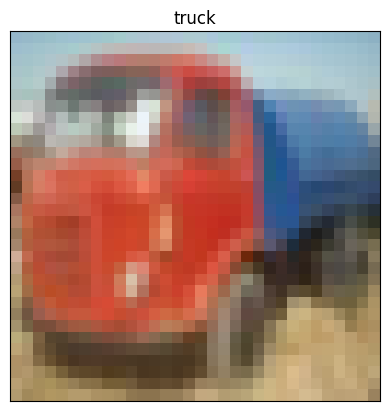

min and max value in image:  30 242


In [10]:
# Call the plot_image function to print out the 100th image in train_images with the backup labels.
plot_image(train_images, 102, train_labels_backup)

# Call the show_min_max function to print the min and max values of the image.
show_min_max(train_images, 100)

## Data Cleaning
Now that the data is loaded, you'll do simple data cleaning. Like the MNIST dataset, you'll change the pixel storage from integers between 0 to 255 to decimal numbers between 0 and 1. To do this, you'll use float32.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [21.0..248.0].


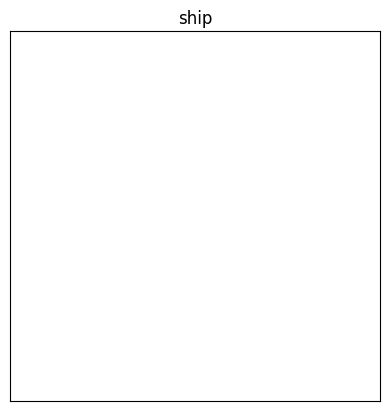

min and max value in image:  0.0 255.0


In [40]:
# Change the image values to between 0 and 1, convert the training data into float32.
train_images = train_images.astype('float32')

# Change the image values to between 0 and 1, convert the test data into float32.
test_images = test_images.astype('float32')

# Call the plot_image function to print out the 100th image in train_images with the backup labels.
plot_image(train_images, 501, train_labels_backup)

# Call the show_min_max function to print the min and max values of the image.
show_min_max(train_images, 500)

# Divide the images by 255 to make sure that each pixel is stored as a value between 0 and 1.
train_images /= 250
test_images /= 250

# Load the train labels.
train_labels = keras.utils.to_categorical(train_labels, num_classes)

# Load the test labels.
test_labels = keras.utils.to_categorical(test_labels, num_classes)

# Building a Network for CIFAR
Now that your data is prepared, it's ready to feed into a network. Since this data is complex, you'll create a convolutional network. A convolutional neural network won't make heavy computations but will draw conclusions about the data.

Since you've worked with a convolutional network, this network will allow you to see how to apply these concepts to a larger, more general dataset. The convolutional neural network will be more robust and take more time and computing power to train.

## Import Model and Layers
To get started, you'll import the Sequential model and layers to perform calculations on the data. The layers you'll add to the network include **Dense**, **Dropout**, **Flatten**, **Conv2D**, **MaxPooling2D**, and **BatchNormalization**.

In [41]:
# Import the Sequential model.
from tensorflow.keras.models import Sequential

# Import the Dense, Dropout, Flatten, Conv2D, MaxPooling2D, and BatchNormalization layers.
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

## Epochs and Model Layers
Every image in the dataset is passed through your model once. Generally, the more epochs you run, the better your results, but the longer it will take to train. Finding the balance between good results and reasonable runtime is a big challenge in training a model. To start, you'll run 10 epochs.

After the model is set up, it's time to add layers to your network. The last convolutional network you made had one round of convolutional layers followed by a pooling layer and then layers to wrap up the network and output a decision.

This network will require more rounds of layers to analyze the details of the pictures. As the layers first start to decipher what's in the image, the network will begin to understand what parts of the image it needs to focus on to understand it. This is what makes convolutional neural networks more effective for image recognition.

In [50]:
# Create a variable called epochs and set the value as 10.
epochs = 17

# Create a variable to store the batch size and set the value as 64.
batch_size = 64

# Create a new model object using the Keras Sequential command.
model = Sequential()

# Add a convolutional layer.
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape = input_shape))

# Add another convolutional layer.
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))

# Add a max pooling layer to condense the information the network has learned so far.
model.add(MaxPooling2D(pool_size=(2,2)))

# Add a dropout layer, so the network doesn't learn to rely on specific neurons.
model.add(Dropout(rate=0.2))

## Batch Normalization
**Batch normalization** is a process that helps standardize the data between layers. In a more complex neural network, as each layer reshapes the data, it can quickly become complicated, and the network can lose sight of the goal. Batch normalization helps to keep each layer on the right track and working towards the desired goal.

Because this data is complex, you'll add two more rounds of convolutional layers, pooling layers, dropout layers, and batch normalization, which will improve the network's performance.

In [51]:
# Add a BatchNormalization layer to your model
model.add(BatchNormalization())

# Adding More Layers
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(1,1)))
model.add(Dropout(rate=0.3))
model.add(BatchNormalization())

# The Final Stage of Layers
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(1,1)))
model.add(Dropout(rate=0.3))
model.add(BatchNormalization())

# The Output Layers
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=num_classes, activation='softmax'))
model.summary()




Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 30, 30, 32)        896       
                                                                 
 conv2d_13 (Conv2D)          (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 batch_normalization_8 (Bat  (None, 14, 14, 64)        256       
 chNormalization)                                                
                                                                 
 conv2d_14 (Conv2D)          (None, 12, 12, 64)       

# Training the Model
Now that you have the network, you'll compile and train it. Like all other networks, you can use Keras's built-in functions. First, you'll **compile** the model and decide on a loss function, optimizer, and metrics. Then, you'll use the **fit** function to train the model using the data. Finally, the model will be evaluated using the **evaluate** function.

## Compile the Network
To compile the network, you'll set the optimizer as the general-purpose Adam algorithm. In addition, you'll use the categorical cross-entropy algorithm to calculate the loss and get the accuracy.

In [52]:
# Add the compile function that calculates the loss and uses the optimizer parameter to set the optimization algorithm..
model.compile(loss=keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

## Training
Now that you have a compiled model, you can fit that model to the actual data that you prepared. The fit stage will use the training data to train the model to recognize numbers.

In [53]:
# Add the fit function and set the input data for the model so the network doesn't rely on a pattern to learn.
model.fit(train_images, train_labels, batch_size=batch_size, epochs=epochs, validation_data=(test_images, test_labels), shuffle=True)

Epoch 1/17
782/782 [==============================] - 109s 137ms/step - loss: 1.4911 - accuracy: 0.4888 - val_loss: 1.2758 - val_accuracy: 0.5419
Epoch 2/17
782/782 [==============================] - 104s 133ms/step - loss: 0.9915 - accuracy: 0.6496 - val_loss: 1.1667 - val_accuracy: 0.6223
Epoch 3/17
782/782 [==============================] - 103s 132ms/step - loss: 0.8300 - accuracy: 0.7062 - val_loss: 0.9754 - val_accuracy: 0.6795
Epoch 4/17
782/782 [==============================] - 105s 134ms/step - loss: 0.7343 - accuracy: 0.7397 - val_loss: 0.8914 - val_accuracy: 0.7020
Epoch 5/17
782/782 [==============================] - 102s 130ms/step - loss: 0.6698 - accuracy: 0.7606 - val_loss: 0.7708 - val_accuracy: 0.7339
Epoch 6/17
782/782 [==============================] - 101s 130ms/step - loss: 0.6089 - accuracy: 0.7858 - val_loss: 0.7441 - val_accuracy: 0.7485
Epoch 7/17
782/782 [==============================] - 105s 134ms/step - loss: 0.5638 - accuracy: 0.8007 - val_loss: 0.8056 -

## Analyzing the Output
Next, you'll analyze the model's output using the **model.evaluate()** function. The function will take the trained model and the test data and produce a set of scores, or metrics, that show how well the model performed on this test data.

In [ ]:
# Save the scores and calculate the loss and accuracy of your model.
scores = model.evaluate(test_images, test_labels, verbose=0)

# Print out the test accuracy.
print('Test accuracy:', scores[1]) # for the cifar_model_v2, the test accuracy was 0.7925

Test accuracy: 0.7925000190734863


## Exporting the Model
Finally, now that you have a finished model, you can export it. Follow these steps to download a copy of your network.

In [55]:
# Export your model
model.save('cifar_model_v2.h5')